In [1]:
import requests
import os

import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares
from scipy.stats import chi2
import scipy as s
import scipy.stats as sc
from scipy.stats import chi2 as chi2_dist
from scipy.stats import t,norm
plt.rcParams['text.usetex'] = False
try:
    import Uomo_lucertola_vecchia as lib2
    print('Successo Importazione')
except ModuleNotFoundError:
    print(f"ERRORE: Impossibile trovare il modulo Uomo_lucertola. Assicurati che 'Uomo_lucertola.py' sia nella stessa cartella del notebook: {os.getcwd()}")
try:
    import Uomo_lucertola as lib
    print('Successo Importazione 2')
except ModuleNotFoundError:
    print(f"ERRORE: Impossibile trovare il modulo Uomo_lucertola2. Assicurati che 'Uomo_lucertola2.py' sia nella stessa cartella del notebook: {os.getcwd()}")


import uncertainties
from uncertainties import ufloat, correlated_values
from uncertainties import ufloat
from uncertainties import unumpy
cartella_dati = "misure"

ERRORE: Impossibile trovare il modulo Uomo_lucertola. Assicurati che 'Uomo_lucertola.py' sia nella stessa cartella del notebook: c:\Users\Andrea\Desktop\lab nucleare
Successo Importazione 2


In [2]:
cartella_dati = "misure"

Time window = 1.14 microsecondi


  VOLTAGGIO = 1 (Taglio tra 2500 e 4050)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 1
      Area =  1.666e+04 ± 256
        mu =       3231 ± 1.71
     sigma =      168.2 ± 2.012
   A_fondo =      6.863 ± 1.525
       tau =       1189 ± 569.7
         c =     0.6217 ± 1.662
        x0 =       2502 ± 25.02
--------------------------------------------------
Chi2 / ndof = 385.27 / 381 = 1.01
p-value     = 0.4292


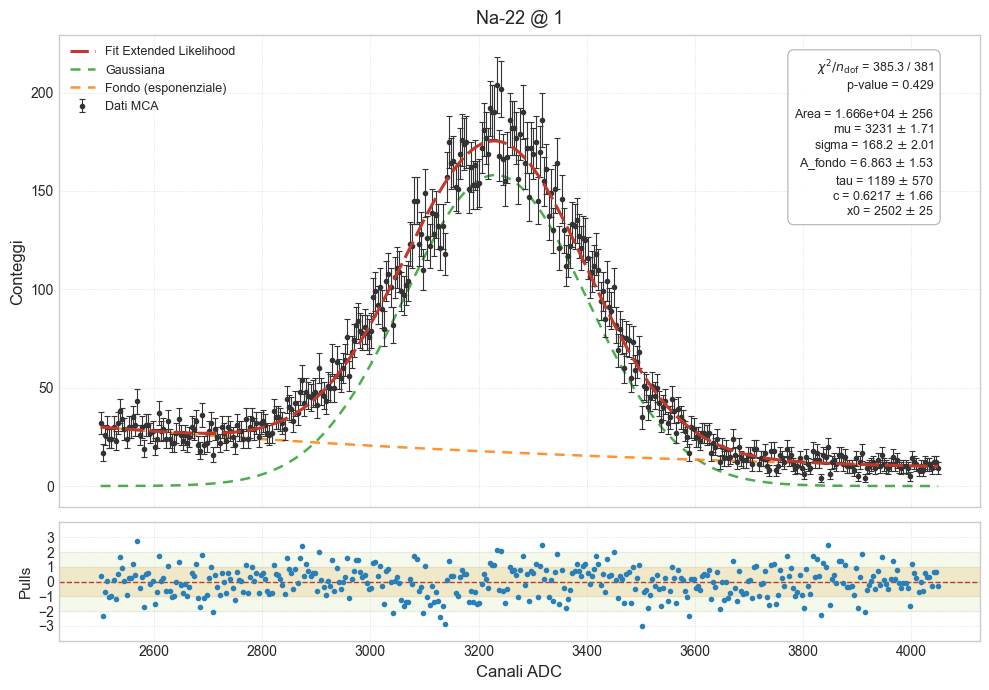

  → Picco = 3231.1833 ± 168.2110

  VOLTAGGIO = 2 (Taglio tra 2500 e 4050)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 2
      Area =   1.04e+04 ± 202.3
        mu =       3230 ± 2.26
     sigma =        170 ± 2.543
   A_fondo =      3.569 ± 0.3724
       tau =      726.5 ± 301.5
         c =      1.347 ± 0.4737
        x0 =       2502 ± 25.02
--------------------------------------------------
Chi2 / ndof = 406.39 / 381 = 1.07
p-value     = 0.1777


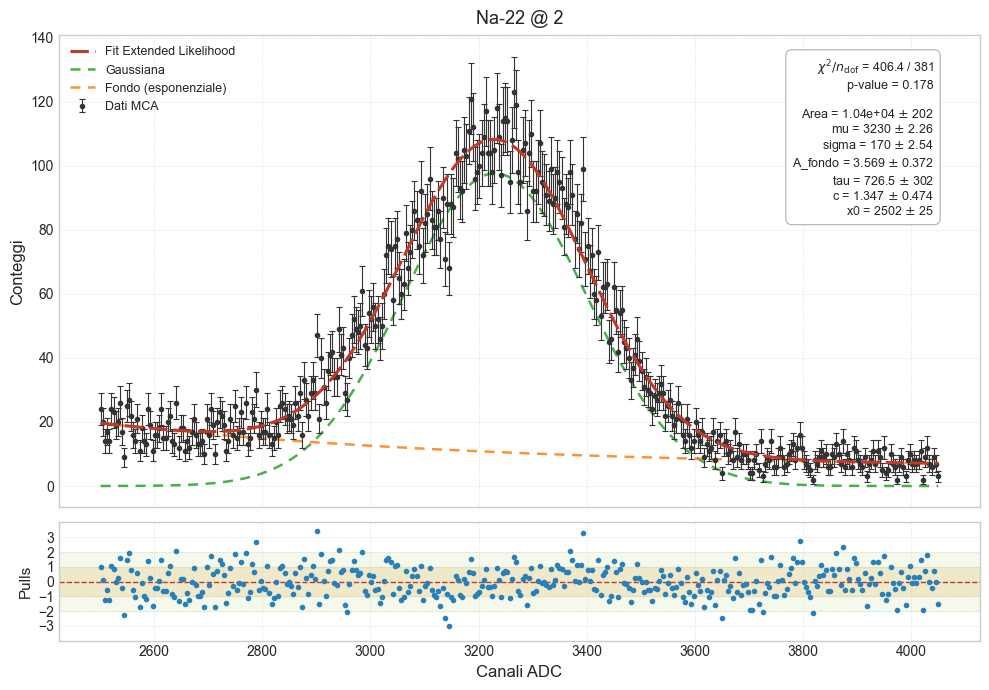

  → Picco = 3230.4381 ± 170.0267

  VOLTAGGIO = 3 (Taglio tra 2500 e 4050)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 3
      Area =   1.04e+04 ± 197.6
        mu =       3236 ± 2.156
     sigma =      166.7 ± 2.472
   A_fondo =       4.43 ± 0.9937
       tau =       1103 ± 575.7
         c =     0.4819 ± 1.105
        x0 =       2502 ± 25.02
--------------------------------------------------
Chi2 / ndof = 368.14 / 381 = 0.97
p-value     = 0.6725


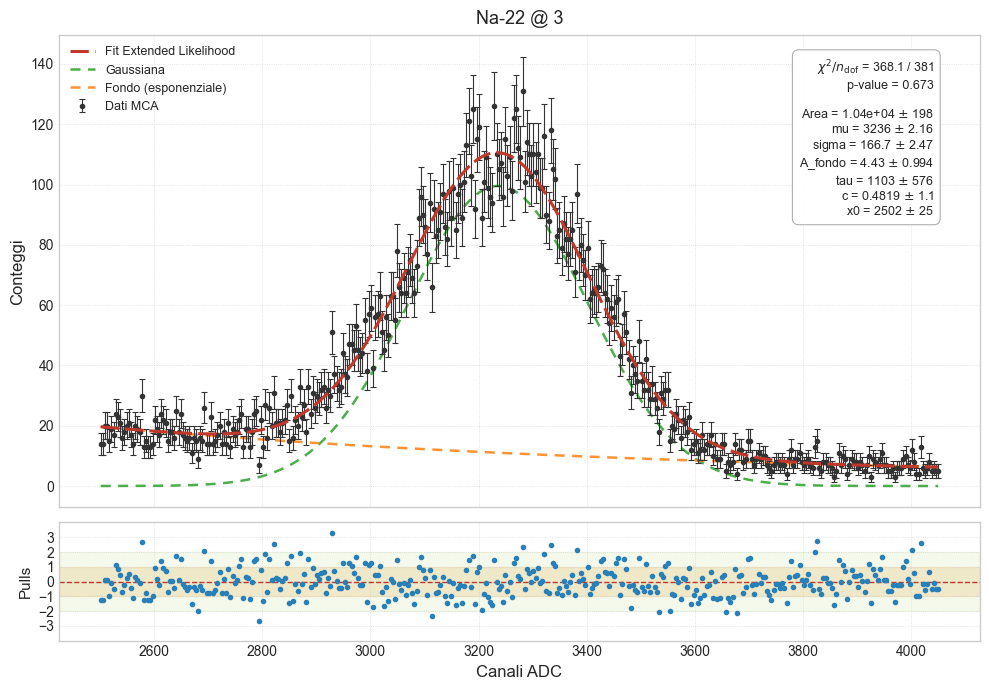

  → Picco = 3236.1442 ± 166.7054


In [14]:
file_coincidenza_list = ["1.dat", "2.dat", "3.dat"]
ch_v_max_array = np.array([4050, 4050, 4050])
ch_v_min_array = np.array([2500, 2500, 2500])
numeri = np.array([1, 2, 3])

risultati_coincidenza = []

for filename, numero, c_v_min, c_v_max in zip(file_coincidenza_list, numeri, ch_v_min_array, ch_v_max_array):
    print(f"\n{'='*60}")
    print(f"  VOLTAGGIO = {numero} (Taglio tra {c_v_min} e {c_v_max})")
    print(f"{'='*60}")
    
    percorso_completo = os.path.join(cartella_dati, filename)
    canali, conteggi = lib.estrai_spettro(percorso_completo, show_plot=False)
    canali, conteggi = lib.rebin(canali, conteggi, n=4)

    # 3. Ora c_min e c_max sono numeri singoli esatti per questo specifico file
    mask = (canali >= c_v_min) & (canali <= c_v_max)
    x_picco = canali[mask]
    y_picco = conteggi[mask]
    
    # Stime iniziali
    mu_guess = x_picco[np.argmax(y_picco)]
    area_guess = np.sum(y_picco)
    fondo_guess = np.mean(y_picco[:5])
    sigma_guess = 15
    x0_guess = x_picco[0]
    c_guess = np.mean(y_picco[-5:])
    if c_guess <= 0: c_guess = 1.0

    # 3. Stima dell'altezza dell'esponenziale 'A_fondo' (coda sinistra)
    sinistra_mean = np.mean(y_picco[:5])
    A_fondo_guess = sinistra_mean - c_guess
    if A_fondo_guess <= 0: A_fondo_guess = 10.0 # Sicurezza

    # 4. Stima di 'tau' (un terzo della finestra)
    tau_guess = (x_picco[-1] - x_picco[0]) / 3.0

    # 5. Stime del picco (mu e sigma)
    mu_guess = x_picco[np.argmax(y_picco)]
    sigma_guess = 15.0 # Per i NaI di solito è un valore iniziale eccellente

    # 6. Stima dell'Area (Totale - Area del fondo a trapezio)
    fondo_medio = (sinistra_mean + c_guess) / 2.0
    area_guess = np.sum(y_picco) - (fondo_medio * len(x_picco))
    if area_guess <= 0: area_guess = np.sum(y_picco) * 0.5
    
    # 4. Corretti i parametri per la parabola (a, b, c)
    parametri_iniziali = {
        'Area': area_guess, 
        'mu': mu_guess, 
        'sigma': sigma_guess, 
        'A_fondo': A_fondo_guess,
        'tau': tau_guess,
        'c': fondo_guess,
        'x0': x0_guess
    }
    # 5. Corretti gli assegnamenti di CDF e PDF
    fit = lib.FitLikelihoodBomberone(
        canali=x_picco,
        conteggi=y_picco,
        modello_cdf=lib.picco_esponenziale_cdf,
        modello_pdf=lib.picco_esponenziale_pdf,
        initial_params=parametri_iniziali,
        title=f"Na-22 @ {numero}"
    )
    
    fit.perform_fit()
    fit.plot_results(componenti=[('Gaussiana', lib.funzione_gaussiana_pdf), ('Fondo (esponenziale)', lib.funzione_esponenziale_pdf)])  
    
    if fit.is_fit_valid:
        mu_ufloat  = ufloat(fit.fit_result['mu'][0], fit.fit_result['mu'][1])
        sig_ufloat = ufloat(fit.fit_result['sigma'][0], fit.fit_result['sigma'][1])
        risultati_coincidenza.append((numero, mu_ufloat, sig_ufloat))
        print(f"  → Picco = {(mu_ufloat._nominal_value):.4f} ± {float(sig_ufloat._nominal_value):.4f}")
    else:
        print(f"  ⚠️ Fit non valido per fit {numero}")


window: numero alto= 0, numero basso=12
lower: numero alto= 0, numero basso=28
channel minimo = 2427,    channel max = 3971
time window = 3.64 microsecondi

In [15]:
distanza_rivelatori = ufloat(0.54, 0.005)
distanza_sorgente_p = ufloat(0.18, 0.005)
distanza_sorgente_g = distanza_rivelatori - distanza_sorgente_p

In [5]:
'''file_list = [
    "roba_random.dat"
]
for f in file_list:
 lib.plot_histogram_from_dat(f, title='PORCODIO')'''

'file_list = [\n    "roba_random.dat"\n]\nfor f in file_list:\n lib.plot_histogram_from_dat(f, title=\'PORCODIO\')'

#  Misure Angolari


Adesso per le misure angoli scatteriamo per diversi angoli. Il numero che ci interessa è il numero di eventi per il picco
cioè l'integrale. Dobbiamo fare uno scatter dell'integrale di eventi per il picco e l'angolo. Prendiamo solamente una direzione dato che il sistema è simmetrico. Ci aspettiamo che la risoluzione angolare dipenda dal raggio del rivelatore fratto la distanza dalla sorgente (angolo solido in una sola direzione)

In [16]:
file_list_angoli = ["misura_gradi0.dat", "misura_gradi3.dat", "misura_gradi6.dat", "misura_gradi9.dat", "misura_gradi12.dat", 
                       "misura_gradi15.dat", "misura_gradi18.dat", "misura_gradi21.dat"]
angoli_rad = np.radians(np.array([0, 3, 6, 9, 12, 15, 18, 21]))  # Convertiamo in radianti]))


  ANGOLO = 0
 RISULTATI FIT LIKELIHOOD: Angolo 0gradi
      Area =  1.107e+04 ± 133
        mu =       3064 ± 1.222
     sigma =      111.3 ± 1.192
   A_fondo =      2.016 ± 1.953
       tau =       1228 ± 1228
         c =     -1.357 ± 2.049
        x0 =       2701 ± 27.01
--------------------------------------------------
Chi2 / ndof = 245.69 / 227 = 1.08
p-value     = 0.188


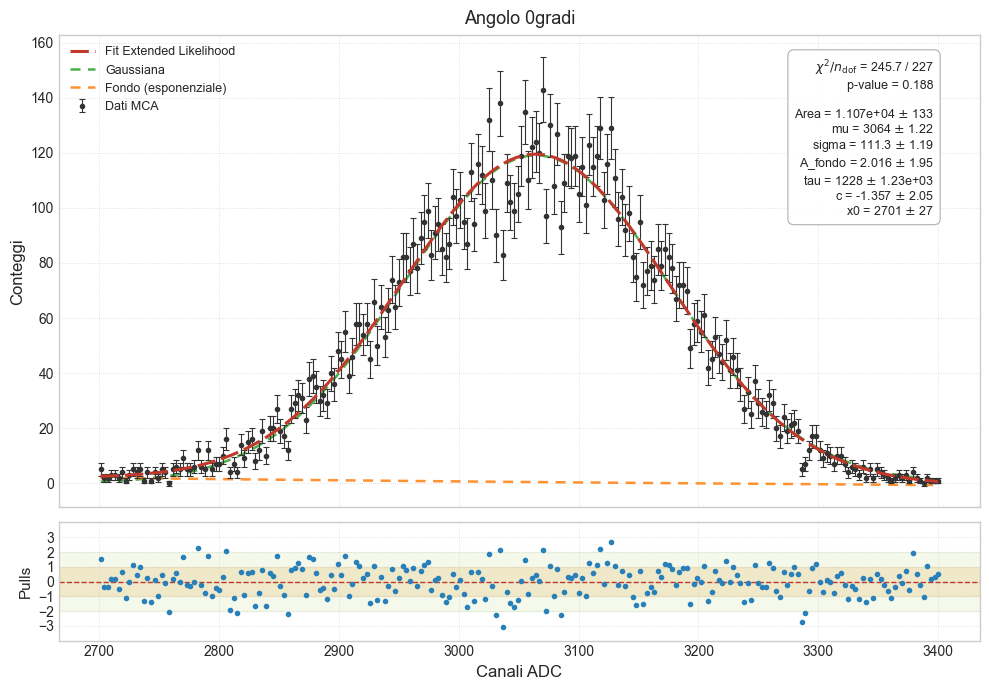

  → Eventi (Area) = 11071+/-133
  → Centroide mu  = 3064.34+/-1.22

  ANGOLO = 3
 RISULTATI FIT LIKELIHOOD: Angolo 3gradi
      Area =       9062 ± 1.996
        mu =       3068 ± 1.042
     sigma =        113 ± 1.054
   A_fondo =       71.4 ± 0.8969
       tau =   6.44e+04 ± 1.996
         c =     -70.82 ± 0.8877
        x0 =       2701 ± 27.01
--------------------------------------------------
Chi2 / ndof = 222.84 / 227 = 0.98
p-value     = 0.5656


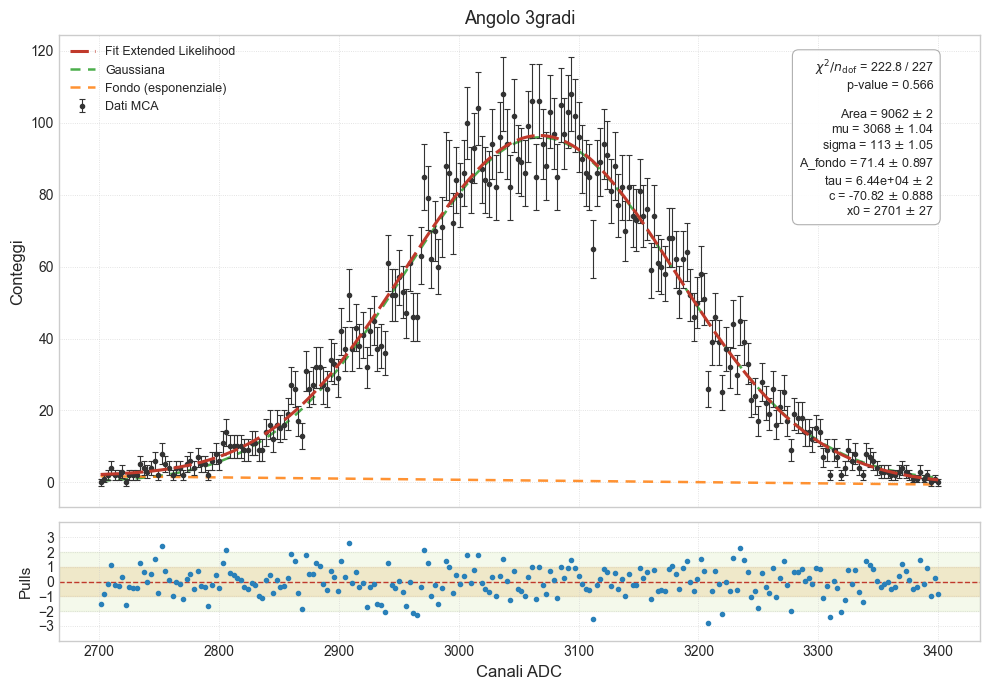

  → Eventi (Area) = 9062+/-2
  → Centroide mu  = 3067.83+/-1.04

  ANGOLO = 6
 RISULTATI FIT LIKELIHOOD: Angolo 6gradi
      Area =       4508 ± 112.7
        mu =       3071 ± 2.312
     sigma =      118.1 ± 2.636
   A_fondo =     0.8227 ± 0.4849
       tau =      601.3 ± 579.9
         c =    -0.2276 ± 0.4662
        x0 =       2701 ± 27.01
--------------------------------------------------
Chi2 / ndof = 252.62 / 227 = 1.11
p-value     = 0.1169


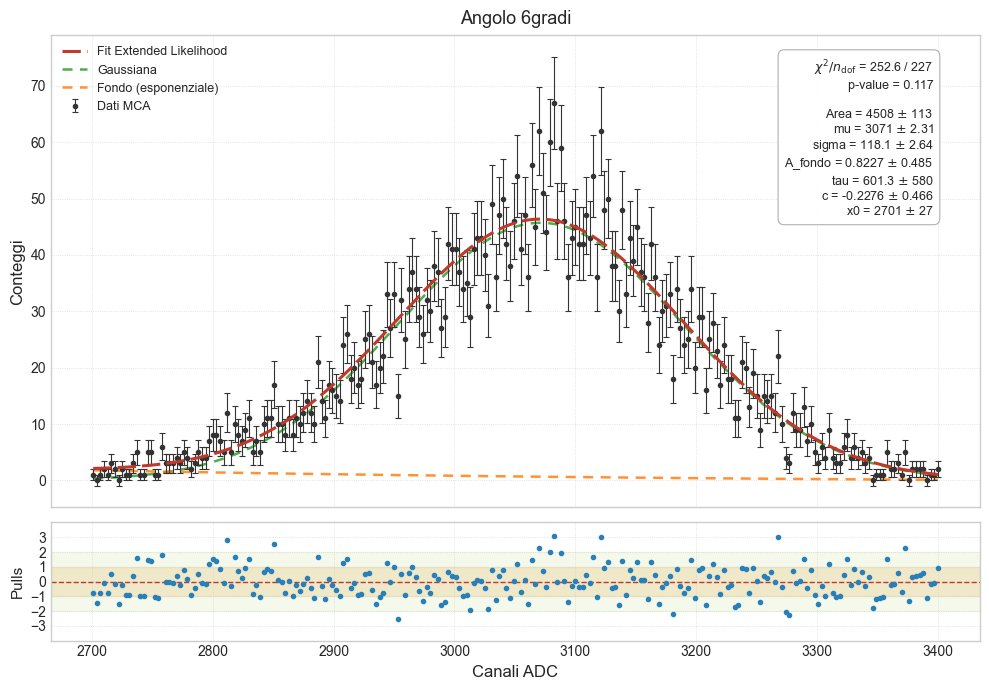

  → Eventi (Area) = 4508+/-113
  → Centroide mu  = 3071.22+/-2.31

  ANGOLO = 9
 RISULTATI FIT LIKELIHOOD: Angolo 9gradi
      Area =       1250 ± 50.96
        mu =       3083 ± 4.102
     sigma =      113.3 ± 4.311
   A_fondo =      2.638 ± 2.039
       tau =       4802 ± 4062
         c =     -2.308 ± 2.069
        x0 =       2701 ± 27.01
--------------------------------------------------
Chi2 / ndof = 221.50 / 227 = 0.98
p-value     = 0.5906


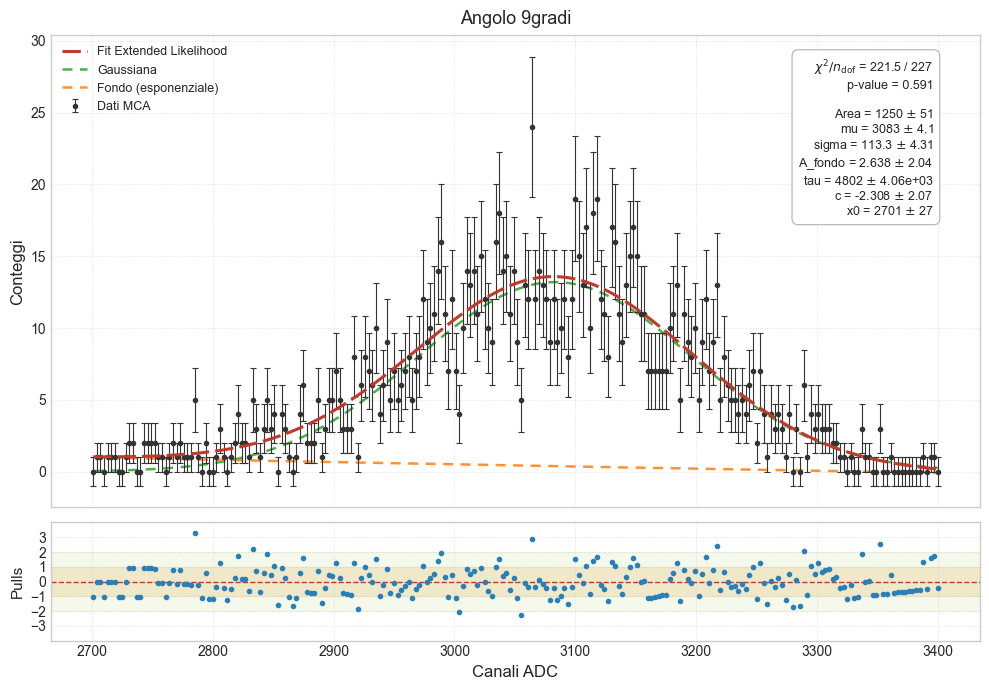

  → Eventi (Area) = 1250+/-51
  → Centroide mu  = 3083.17+/-4.10


In [17]:
angoli = np.array([0, 3, 6, 9, 12, 15, 18, 21])
angoli2 = np.array([0, 3, 6, 9])
c_v_max2 = 3400
c_v_min2 = 2700
risultati_coincidenza2 = []

file_list_angoli2 = ["misura_gradi0.dat", "misura_gradi3.dat", "misura_gradi6.dat", "misura_gradi9.dat"]

for filename, ang in zip(file_list_angoli2, angoli2):
    print(f"\n{'='*60}")
    print(f"  ANGOLO = {ang}")
    print(f"{'='*60}")
    
    percorso_completo = os.path.join(cartella_dati, filename)
    canali, conteggi = lib.estrai_spettro(percorso_completo, show_plot=False)
    canali, conteggi = lib.rebin(canali, conteggi, n=3)

    # 3. Ora c_min e c_max sono numeri singoli esatti per questo specifico file
    mask = (canali >= c_v_min2) & (canali <= c_v_max2)
    x_picco = canali[mask]
    y_picco = conteggi[mask]
    
    # Stime iniziali
    mu_guess = x_picco[np.argmax(y_picco)]
    area_guess = np.sum(y_picco)
    fondo_guess = np.mean(y_picco[:5])
    sigma_guess = 15
    x0_guess = x_picco[0]
    c_guess = np.mean(y_picco[-5:])
    if c_guess <= 0: c_guess = 1.0

    # 3. Stima dell'altezza dell'esponenziale 'A_fondo' (coda sinistra)
    sinistra_mean = np.mean(y_picco[:5])
    A_fondo_guess = sinistra_mean - c_guess
    if A_fondo_guess <= 0: A_fondo_guess = 10.0 # Sicurezza

    # 4. Stima di 'tau' (un terzo della finestra)
    tau_guess = (x_picco[-1] - x_picco[0]) / 3.0

    # 5. Stime del picco (mu e sigma)
    mu_guess = x_picco[np.argmax(y_picco)]
    sigma_guess = 15.0 # Per i NaI di solito è un valore iniziale eccellente

    # 6. Stima dell'Area (Totale - Area del fondo a trapezio)
    fondo_medio = (sinistra_mean + c_guess) / 2.0
    area_guess = np.sum(y_picco) - (fondo_medio * len(x_picco))
    if area_guess <= 0: area_guess = np.sum(y_picco) * 0.5
    
    # 4. Corretti i parametri per la parabola (a, b, c)
    parametri_iniziali = {
        'Area': area_guess, 
        'mu': mu_guess, 
        'sigma': sigma_guess, 
        'A_fondo': A_fondo_guess,
        'tau': tau_guess,
        'c': fondo_guess,
        'x0': x0_guess
    }
    # 5. Corretti gli assegnamenti di CDF e PDF
    fit = lib.FitLikelihoodBomberone(
        canali=x_picco,
        conteggi=y_picco,
        modello_cdf=lib.picco_esponenziale_cdf,
        modello_pdf=lib.picco_esponenziale_pdf,
        initial_params=parametri_iniziali,
        title=f"Angolo {ang}gradi"
    )
    
    fit.perform_fit()
    fit.plot_results(componenti=[('Gaussiana', lib.funzione_gaussiana_pdf), ('Fondo (esponenziale)', lib.funzione_esponenziale_pdf)])  
    
    if fit.is_fit_valid:
        # Estrai mu, sigma e soprattutto l'AREA come oggetti ufloat
        mu_ufloat   = ufloat(fit.fit_result['mu'][0], fit.fit_result['mu'][1])
        sig_ufloat  = ufloat(fit.fit_result['sigma'][0], fit.fit_result['sigma'][1])
        area_ufloat = ufloat(fit.fit_result['Area'][0], fit.fit_result['Area'][1])
        
        # ⚠️ CORREZIONI: 
        # 1. Usa risultati_coincidenza2 (la lista definita prima del ciclo)
        # 2. Usa 'ang' al posto di 'numero'
        # 3. Salva anche area_ufloat nella tupla!
        risultati_coincidenza2.append((ang, area_ufloat, mu_ufloat, sig_ufloat))
        
        # Stampiamo l'Area trovata (oltre al centroide)
        print(f"  → Eventi (Area) = {area_ufloat:.0f}")
        print(f"  → Centroide mu  = {mu_ufloat:.2f}")
    else:
        print(f"  ⚠️ Fit non valido per l'angolo {ang}")

In [19]:
#Per stimare l'area del picco per la configurazione a 12 e 15 gradi usiamo semplicemente la somma
#area = np.sum(y_picco)     errore_area = np.sqrt(area)
file_angoli_estremi = {
    12: "misura_gradi12.dat", 
    15: "misura_gradi15.dat"
}

canale_min = 2900
canale_max = 3250
risultati_somma = []

for ang, filename in file_angoli_estremi.items():
    print(f"\n{'='*40}")
    print(f"  ANGOLO = {ang}° (Integrazione numerica)")
    print(f"{'='*40}")
    
    try:
        percorso_completo = os.path.join(cartella_dati, filename)
        conteggi = np.loadtxt(percorso_completo)

        conteggi_roi = conteggi[canale_min : canale_max + 1]
        
        area_totale = np.sum(conteggi_roi)
        
        #errore Poissoniano (radice quadrata dei conteggi)
        errore_area = np.sqrt(area_totale)
        area_ufloat = ufloat(area_totale, errore_area)
        
        #lista = (Area, nessun mu e nessun sigma)
        risultati_somma.append((ang, area_ufloat))
        
        print(f"  → File elaborato: {percorso_completo}")
        print(f"  → Finestra usata: [{canale_min}, {canale_max}]")
        print(f"  → Area (Eventi):  {area_totale:.0f} ± {errore_area:.1f}")
        
    except FileNotFoundError:
        print(f"  ⚠️ Errore: Il file '{percorso_completo}' non è stato trovato!")

print("\n--- Riepilogo dei dati calcolati ---")
for punto in risultati_somma:
    print(f"Angolo: {punto[0]}° | Area: {punto[1]:.0f}")


  ANGOLO = 12° (Integrazione numerica)
  → File elaborato: misure\misura_gradi12.dat
  → Finestra usata: [2900, 3250]
  → Area (Eventi):  79 ± 8.9

  ANGOLO = 15° (Integrazione numerica)
  → File elaborato: misure\misura_gradi15.dat
  → Finestra usata: [2900, 3250]
  → Area (Eventi):  41 ± 6.4

--- Riepilogo dei dati calcolati ---
Angolo: 12° | Area: 79+/-9
Angolo: 15° | Area: 41+/-6


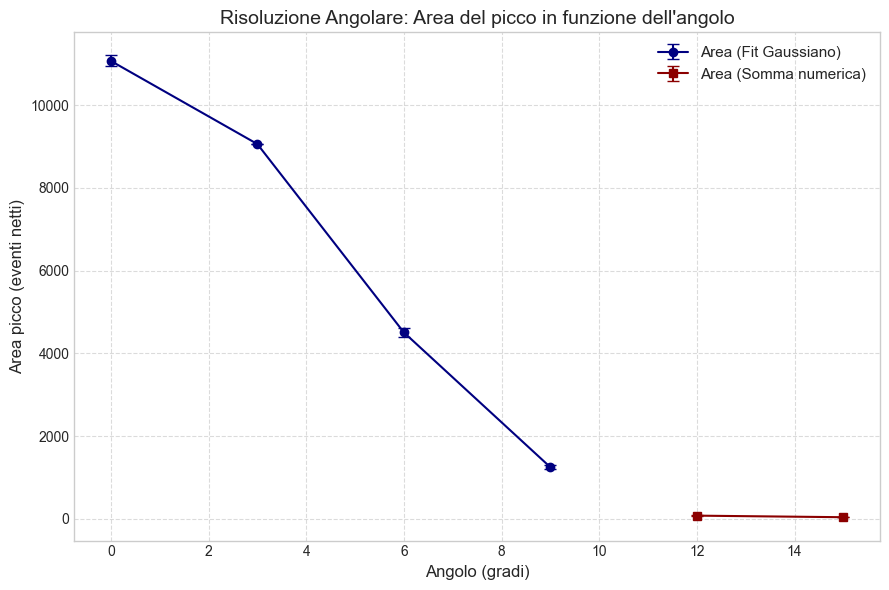

In [22]:
angoli_fit = []
aree_fit = []
err_fit = []
for r in risultati_coincidenza2:
    angoli_fit.append(r[0])
    aree_fit.append(r[1].n)
    err_fit.append(r[1].s)
'''
print("Aree trovate dal fit:")
for area, err in zip(aree_fit, err_fit):
    print(f"{area:.3f} ± {err:.3f}")'''

angoli_somma = []
aree_somma = []
err_somma = []
for r in risultati_somma:
    angoli_somma.append(r[0])
    aree_somma.append(r[1].n)
    err_somma.append(r[1].s)
'''
print("Angoli (Fit):", angoli_fit)
print("Aree (Fit):", aree_fit)
print("Angoli (Somma):", angoli_somma)
print("Aree (Somma):", aree_somma)'''

# 3. Creazione del grafico
plt.figure(figsize=(9, 6))

#punti del Fit (pallini blu)
plt.errorbar(angoli_fit, aree_fit, yerr=err_fit, 
             fmt='o-', color='navy', capsize=4, label='Area (Fit Gaussiano)')

#punti della Somma Diretta (quadratini rossi)
plt.errorbar(angoli_somma, aree_somma, yerr=err_somma, 
             fmt='s-', color='darkred', capsize=4, label='Area (Somma numerica)')

plt.xlabel('Angolo (gradi)', fontsize=12)
plt.ylabel('Area picco (eventi netti)', fontsize=12)
plt.title('Risoluzione Angolare: Area del picco in funzione dell\'angolo', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

Fit Gaussiano per risoluzione angolare

--- Esecuzione Fit con Metodo: ODR ---
Fit completato.

--- Risultati del Fit (ODR) ---
Fit Valido: Sì

Parametri Ottimizzati:
  A = 1.109e+04 ± 1.7e+02
  mu = 8.827e-05 ± 0.26
  sigma = 3.996 ± 0.17
  C = 26.87 ± 12

Statistiche del Fit:
  Chi-quadro (χ²): 11.7187
  Gradi di libertà (DoF): 7
  Chi-quadro Ridotto (χ²/DoF): 1.6741
  p-value: 0.1102


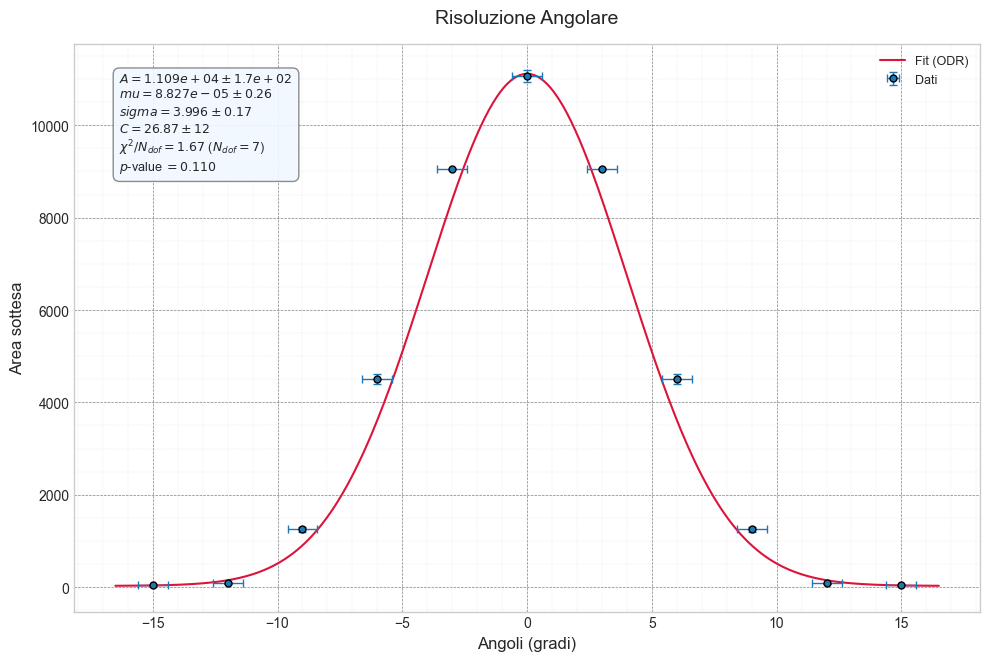

9.4+/-0.4


In [23]:
angoli_tot = np.array(angoli_fit + angoli_somma)
aree_tot = np.array(aree_fit + aree_somma)
err_tot = np.array(err_fit + err_somma)

mask = angoli_tot > 0
angoli_neg = -angoli_tot[mask]
aree_neg = aree_tot[mask]
err_neg = err_tot[mask]

angoli_simmetrici = np.concatenate((angoli_neg[::-1], angoli_tot))
aree_simmetriche = np.concatenate((aree_neg[::-1], aree_tot))
err_simmetrici1 = np.concatenate((err_neg[::-1], err_tot))
err_simmetrici = np.where(err_simmetrici1 == 0, 1.0, err_simmetrici1)
err_ang = np.full_like(angoli_simmetrici, 0.6, dtype=float)

def gaussiana(x, A, mu, sigma, C):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2)) + C

data_ang = {
    'x': angoli_simmetrici,
    'y': aree_simmetriche,
    'sigma_y': err_simmetrici,
    'sigma_x': err_ang
}

parametri_iniziali_ang = {
    'A': 11000, 
    'mu': 0.0,
    'sigma':3.0, 
    'C': 10,
}

# 5. Esecuzione Fit
fit_ang = lib.FitBomberone2(
    model_func = gaussiana,
    data_arrays = data_ang,
    initial_params = parametri_iniziali_ang,
    fit_method = 'ODR',
    xlabel = 'Angoli (gradi)',
    ylabel = 'Area sottesa',
    title = 'Risoluzione Angolare'
)

fit_ang.perform_fit()
fit_ang.print_results()
fit_ang.plot_results(info_box_pos='upper left')

sigma_ang = ufloat(fit_ang.fit_result['sigma'][0], fit_ang.fit_result['sigma'][1])
print(sigma_ang * 2.355)

# Bho roba di Gemini

Beta: [1.23701656e+04 5.63818621e+00 5.39800804e+01]
Beta Std Error: [1.22060880e+03 4.75632852e-01 6.93983155e+00]
Beta Covariance: [[ 4.17497908e+05 -8.43182859e+01 -1.13454170e+01]
 [-8.43182859e+01  6.33935394e-02 -8.82460769e-03]
 [-1.13454170e+01 -8.82460769e-03  1.34958167e+01]]
Residual Variance: 3.568606709102808
Inverse Condition #: 0.47061416500154296
Reason(s) for Halting:
  Sum of squares convergence

Ampiezza A = 12370.17 ± 1220.61
Alpha     = 5.6382° ± 0.4756°
Fondo     = 53.98 ± 6.94
FWHM      = 9.11° ± 0.77°


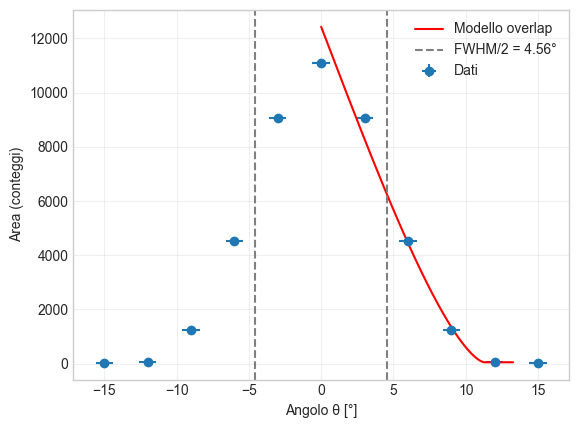

In [11]:
import numpy as np
from scipy.odr import Model, RealData, ODR
from scipy.optimize import brentq
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Funzione di overlap area per due cerchi uguali di raggio alpha
#    theta : separazione angolare (gradi)
#    alpha : semi‑apertura del rivelatore (gradi)
# ------------------------------------------------------------
def overlap_area(theta, alpha):
    """
    Restituisce l'area di sovrapposizione di due cerchi di raggio alpha
    con centri a distanza theta. Se theta >= 2*alpha → 0.
    """
    theta = np.abs(theta)          # simmetria
    # Maschera per theta <= 2*alpha (altrimenti 0)
    valid = theta <= 2*alpha
    area = np.zeros_like(theta)
    t = theta[valid]
    a = alpha
    # Formula per due cerchi uguali
    term1 = 2 * a**2 * np.arccos(t / (2*a))
    term2 = 0.5 * t * np.sqrt(4 * a**2 - t**2)
    area[valid] = term1 - term2
    return area

# ------------------------------------------------------------
# 2. Modello per ODR: f = A * overlap_area(theta, alpha)/overlap_area(0,alpha) + B
#    (normalizzato a 1 per theta=0, poi scalato da A)
# ------------------------------------------------------------
def model_func(params, theta):
    A, alpha, B = params
    # Valore massimo per theta=0 (overlap totale)
    max_overlap = np.pi * alpha**2          # area cerchio intero
    # overlap normalizzato
    overlap_norm = overlap_area(theta, alpha) / max_overlap
    return A * overlap_norm + B

# ------------------------------------------------------------
# 3. Preparazione dati (supponendo già definiti gli array)
#    angoli_simmetrici, aree_simmetriche, err_simmetrici, err_ang
# ------------------------------------------------------------
# Esempio (sostituisci con i tuoi dati reali)
# angoli_simmetrici = ...
# aree_simmetriche   = ...
# err_simmetrici     = ...
# err_ang            = np.full_like(angoli_simmetrici, 0.6, dtype=float)

# Stima iniziale dei parametri
A0 = np.max(aree_simmetriche) - np.min(aree_simmetriche)
alpha0 = 4.04      # valore geometrico atteso
B0 = np.min(aree_simmetriche)

# Crea l'oggetto per ODR
data = RealData(angoli_simmetrici, aree_simmetriche,
                sx=err_ang, sy=err_simmetrici)
model = Model(model_func)
odr = ODR(data, model, beta0=[A0, alpha0, B0])

# Esegui il fit
output = odr.run()
output.pprint()   # stampa i risultati

# Parametri stimati
A_fit, alpha_fit, B_fit = output.beta
A_err, alpha_err, B_err = output.sd_beta

# ------------------------------------------------------------
# 4. Calcolo della FWHM dalla curva fittata (al netto del fondo)
# ------------------------------------------------------------
def model_signal(theta, A, alpha):
    """Parte di segnale sopra il fondo"""
    max_overlap = np.pi * alpha**2
    return A * overlap_area(theta, alpha) / max_overlap

# Altezza massima del segnale (a theta=0)
signal_max = model_signal(0.0, A_fit, alpha_fit)

# Funzione obiettivo per trovare il punto a metà altezza
def half_func(theta):
    return model_signal(theta, A_fit, alpha_fit) - signal_max/2.0

# Il punto a metà altezza si trova tra 0 e 2*alpha
try:
    theta_half = brentq(half_func, 0.0, 2*alpha_fit)
    FWHM = 2 * theta_half
except ValueError:
    # Se il segnale non scende mai sotto metà (es. fondo dominante)
    FWHM = np.nan
    print("Impossibile calcolare FWHM: il segnale non dimezza entro il cutoff.")

# Errore sulla FWHM: propagazione semplice (differenziale)
# FWHM = 2 * theta_half, d(FWHM) ≈ 2 * |dtheta_half/dalpha| * alpha_err
# Poiché theta_half dipende da alpha, si può stimare numericamente:
delta = 1e-4
theta_plus = brentq(lambda t: model_signal(t, A_fit, alpha_fit+delta)-signal_max/2, 0, 2*(alpha_fit+delta))
theta_minus = brentq(lambda t: model_signal(t, A_fit, alpha_fit-delta)-signal_max/2, 0, 2*alpha_fit)
dtheta_dalpha = (theta_plus - theta_minus) / (2*delta)
FWHM_err = 2 * np.abs(dtheta_dalpha) * alpha_err

print(f"\nAmpiezza A = {A_fit:.2f} ± {A_err:.2f}")
print(f"Alpha     = {alpha_fit:.4f}° ± {alpha_err:.4f}°")
print(f"Fondo     = {B_fit:.2f} ± {B_err:.2f}")
print(f"FWHM      = {FWHM:.2f}° ± {FWHM_err:.2f}°")

# ------------------------------------------------------------
# 5. Grafico
# ------------------------------------------------------------
theta_plot = np.linspace(0, 2*alpha_fit+2, 200)
plt.errorbar(angoli_simmetrici, aree_simmetriche,
             xerr=err_ang, yerr=err_simmetrici,
             fmt='o', label='Dati')
plt.plot(theta_plot, model_func([A_fit, alpha_fit, B_fit], theta_plot),
         'r-', label='Modello overlap')
plt.axvline(FWHM/2, color='gray', linestyle='--', label=f'FWHM/2 = {FWHM/2:.2f}°')
plt.axvline(-FWHM/2, color='gray', linestyle='--')
plt.xlabel('Angolo θ [°]')
plt.ylabel('Area (conteggi)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()